# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The goal of this playbook is to turn the validated Week-5/Week-6 Random Forest into a ranked, human-reviewable content queue.

The model estimates `P(declining)` for each page. I combine that score with transparent content checks to create reason codes and action labels.

The reason codes are non-exclusive: a page can have multiple risk signals at the same time.

### Reason codes

- `stale_ctr_underperformer` — visible page, 90+ days since update, and CTR below its position-tier baseline.
- `high_decline_risk` — Random Forest `decline_proba >= 0.6`.
- `deep_thin_content` — page ranks beyond position 50 and has fewer than 1,500 words.
- `mature_never_refreshed` — page is 270+ days old, has not been updated for 270+ days, and still receives impressions.
- `stable_top_performer` — strong search position, real traffic, and low decline risk; this is a protection signal rather than a refresh signal.

### Action mapping

| Reason-code pattern | Action | Meaning |
|---|---|---|
| `stable_top_performer` fires | `protect` | Leave the page alone and monitor for regression |
| 2+ risk codes fire | `refresh_priority` | Highest-priority human review |
| Exactly 1 risk code fires | `refresh_review` | Review if capacity allows |
| No codes fire | `monitor` | No immediate action; score again next cycle |

### Priority score

For risk pages, the priority score is:

`decline_proba × capped impressions_90d`

Impressions are capped at the 99th percentile so a small number of extremely large pages cannot dominate the entire queue.

This is a prioritization score, not a prediction of business impact.

### Value proxy

The value proxy is:

`clicks_90d × cpc`

I do not use impressions × CPC because impressions are not billable clicks.

The queue is intended to support human review, not automatic content changes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "has_word_count",
]

CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

TARGET = "is_declining_label"

df = df_raw.copy()

df = df[
    (df["impressions_90d"] > 0) &
    (df["content_age_days"] >= 90)
].copy()

df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)

df[TARGET] = (
    df["trend_direction"]
    .str.lower()
    .eq("down")
    .astype(int)
)

df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])

df["has_word_count"] = df["word_count"].notna().astype(int)

for col in NUMERIC_FEATURES:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

for col in CATEGORICAL_FEATURES:
    df[col] = (
        df[col]
        .fillna("unknown")
        .astype(str)
        .replace({"nan": "unknown", "": "unknown"})
    )

print(f"Prepared rows: {len(df):,}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Declining proxy rate: {df[TARGET].mean():.1%}")

Prepared rows: 30,000
Clients: 32
Declining proxy rate: 54.2%


## 2. Build the ranked queue

The queue is generated using the same client-grouped validation design established in Week 6.

The Random Forest is trained on the training clients and produces a `decline_proba` score for the held-out clients. For the final action playbook, the validated model is then used to score the full starter-sample inventory.

Each page receives:
- a decline-risk probability,
- zero or more reason codes,
- one action,
- a priority score,
- and a value proxy.

The queue is sorted so that pages with multiple risk signals and greater search visibility appear earlier.

In [2]:
# Client-grouped split: same deterministic design used in W06
clients = sorted(df["client_id"].unique())
test_clients = set(clients[::5])

train_grp = df[~df["client_id"].isin(test_clients)].copy()
test_grp = df[df["client_id"].isin(test_clients)].copy()

print(f"Training rows: {len(train_grp):,}")
print(f"Scoring/test rows: {len(test_grp):,}")
print(f"Training clients: {train_grp['client_id'].nunique()}")
print(f"Held-out clients: {test_grp['client_id'].nunique()}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    (
        "cat",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        CATEGORICAL_FEATURES
    ),
])

rf_pipeline = Pipeline([
    ("pre", preprocessor),
    (
        "clf",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    )
])

X_train = train_grp[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_grp[TARGET]

rf_pipeline.fit(X_train, y_train)

print("Validated Random Forest trained successfully.")

Training rows: 24,490
Scoring/test rows: 5,510
Training clients: 25
Held-out clients: 7
Validated Random Forest trained successfully.


In [3]:
# Score the complete filtered inventory for the action playbook
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

df["decline_proba"] = rf_pipeline.predict_proba(X_all)[:, 1]

print("Scored pages:", len(df))
print(
    "Decline probability range:",
    f"{df['decline_proba'].min():.3f}",
    "to",
    f"{df['decline_proba'].max():.3f}"
)

Scored pages: 30000
Decline probability range: 0.000 to 0.920


In [4]:
# Position-tier CTR baseline
# Use the median CTR within each position tier as the transparent reference.
ctr_baseline = df.groupby("position_tier")["ctr"].median()

df["position_tier_ctr_baseline"] = (
    df["position_tier"].map(ctr_baseline)
)

# Reason 1: stale + visible + CTR under position-tier baseline
df["reason_stale_ctr"] = (
    (df["impressions_90d"] >= 500) &
    (df["days_since_last_update"] >= 90) &
    (df["ctr"] < df["position_tier_ctr_baseline"])
)

# Reason 2: high model-estimated decline risk
df["reason_high_risk"] = (
    df["decline_proba"] >= 0.60
)

# Reason 3: deep position + thin content
df["reason_deep_thin"] = (
    (df["avg_position"] > 50) &
    (df["word_count"] < 1500)
)

# Reason 4: mature + not recently refreshed + visible
df["reason_mature_never_refreshed"] = (
    (df["content_age_days"] >= 270) &
    (df["days_since_last_update"] >= 270) &
    (df["impressions_90d"] > 0)
)

# Reason 5: stable top performer
df["reason_stable_top"] = (
    (df["avg_position"] <= 3) &
    (df["decline_proba"] < 0.30) &
    (df["impressions_90d"] > 0)
)

def build_reason_codes(row):
    codes = []

    if row["reason_stale_ctr"]:
        codes.append("stale_ctr_underperformer")

    if row["reason_high_risk"]:
        codes.append("high_decline_risk")

    if row["reason_deep_thin"]:
        codes.append("deep_thin_content")

    if row["reason_mature_never_refreshed"]:
        codes.append("mature_never_refreshed")

    if row["reason_stable_top"]:
        codes.append("stable_top_performer")

    return "|".join(codes)

df["reason_codes"] = df.apply(build_reason_codes, axis=1)

print("Reason codes generated.")
print()
print(df["reason_codes"].replace("", "none").value_counts().head(15))

Reason codes generated.

reason_codes
none                                           14548
high_decline_risk                              10934
stable_top_performer                            1651
stale_ctr_underperformer|high_decline_risk      1260
deep_thin_content                                767
stale_ctr_underperformer                         759
high_decline_risk|deep_thin_content               46
mature_never_refreshed                            22
high_decline_risk|mature_never_refreshed           8
deep_thin_content|mature_never_refreshed           4
mature_never_refreshed|stable_top_performer        1
Name: count, dtype: int64


In [5]:
RISK_CODES = {
    "stale_ctr_underperformer",
    "high_decline_risk",
    "deep_thin_content",
    "mature_never_refreshed",
}

def assign_action(row):
    codes = set(row["reason_codes"].split("|")) if row["reason_codes"] else set()

    if "stable_top_performer" in codes:
        return "protect"

    risk_count = len(codes.intersection(RISK_CODES))

    if risk_count >= 2:
        return "refresh_priority"

    if risk_count == 1:
        return "refresh_review"

    return "monitor"

df["action"] = df.apply(assign_action, axis=1)

print("Action distribution:")
print(df["action"].value_counts())

Action distribution:
action
monitor             14548
refresh_review      12482
protect              1652
refresh_priority     1318
Name: count, dtype: int64


In [6]:
# Cap impressions at the 99th percentile so extreme outliers
# cannot dominate the ranking.
impression_cap = df["impressions_90d"].quantile(0.99)

df["impressions_capped"] = df["impressions_90d"].clip(
    upper=impression_cap
)

df["priority_score"] = (
    df["decline_proba"] *
    df["impressions_capped"]
)

# Value proxy: clicks × CPC
df["value_proxy_usd"] = (
    df["clicks_90d"].fillna(0) *
    df["cpc"].fillna(0)
)

print(f"99th percentile impression cap: {impression_cap:,.2f}")
print(
    f"Total value proxy: "
    f"${df['value_proxy_usd'].sum():,.2f}"
)

99th percentile impression cap: 73,505.83
Total value proxy: $126,219.79


In [7]:
queue = df[
    [
        "content_id",
        "client_id",
        "action",
        "reason_codes",
        "position_tier",
        "decline_proba",
        "priority_score",
        "value_proxy_usd",
        "impressions_90d",
        "clicks_90d",
        "cpc",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
        "word_count",
    ]
].copy()

queue = queue.sort_values(
    ["action", "priority_score"],
    ascending=[True, False]
).reset_index(drop=True)

print(f"Action queue: {len(queue):,} scored pages")
print()
print(queue["action"].value_counts())
print()

print("Top refresh_priority rows:")
display(
    queue[
        queue["action"] == "refresh_priority"
    ].head(10)
)

Action queue: 30,000 scored pages

action
monitor             14548
refresh_review      12482
protect              1652
refresh_priority     1318
Name: count, dtype: int64

Top refresh_priority rows:


,content_id,client_id,action,reason_codes,position_tier,decline_proba,priority_score,value_proxy_usd,impressions_90d,clicks_90d,cpc,avg_position,content_age_days,days_since_last_update,word_count
16200,content_fb4bf6555c79,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.742048,54544.822621,0.00,84093,3,0.00,45.6,299,104,6681.0
16201,content_87dfc063bf4e,client_19581e27de,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_1,0.683163,50216.435552,10.08,90991,72,0.14,4.5,153,104,0.0
16202,content_54baba704595,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.679546,49950.588195,0.00,130617,8,0.00,47.0,286,104,5813.0
16203,content_32cfb0b2fccf,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.670540,49288.563820,0.00,89361,10,0.00,38.5,287,104,6244.0
16204,content_9a29e017706f,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.694690,48955.470850,0.00,70471,13,0.00,40.8,299,104,5474.0
16205,content_d0cc5baa4995,client_19581e27de,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_1,0.665426,48912.723408,0.00,83651,28,0.00,6.6,148,104,0.0
16206,content_e752a4e03dd3,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.665012,48882.258390,0.00,130892,15,0.00,23.9,287,104,6442.0
16207,content_8b36799b7e44,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.648042,47634.893242,0.00,141400,23,0.00,32.0,299,104,7394.0
16208,content_f8de7d4cee60,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.607279,44638.537316,0.00,89803,21,0.00,30.8,144,104,5055.0
16209,content_013a5d3dfc26,client_6208ef0f77,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.679202,44590.992846,0.00,65652,9,0.00,25.7,148,104,4540.0


## 3. Human review + no-go list

The action queue is designed to prioritize human review, not automate content decisions.

A `refresh_priority` page should be reviewed first because it has multiple independent risk signals. The model score provides ranking information, while the reason codes provide a transparent explanation of why the page surfaced.

### Required human check before acting

For every `refresh_priority` page, the reviewer should:

1. Open the live page and confirm that the reason code matches the page's actual condition.
2. Compare recent performance with the previous period to confirm that the decline is still active.
3. Check for tracking or measurement problems before interpreting zero or unusually low engagement as a content problem.
4. Check for possible keyword cannibalization or competing sibling pages.
5. Review the page's search position and CTR in context rather than treating the model score as a diagnosis.
6. Decide whether the appropriate action is actually to refresh, leave unchanged, monitor, or investigate further.

The model's `decline_proba` is a ranking score. It does not establish why a page changed or whether a content refresh will improve performance.

### No-go list

The following actions must not be automated from this score:

- Automatically publishing or editing content.
- Automatically deleting or deprioritizing pages labeled `monitor`.
- Presenting raw `decline_proba` or `priority_score` to clients without human explanation.
- Ranking or comparing client content teams using the model score.
- Automatically reallocating budgets based only on the value proxy.
- Treating a high score as proof that a page will decline.
- Treating a flagged page as proof that refreshing it will improve performance.

The intended workflow is:

**Model ranking → human review → contextual checks → human decision → action → re-score later.**

In [8]:
# Human-review summary

review_queue = queue[
    queue["action"].isin(["refresh_priority", "refresh_review"])
].copy()

print(f"Pages requiring some level of review: {len(review_queue):,}")
print()

print("Review queue by action:")
print(review_queue["action"].value_counts())
print()

print("Reason-code frequency among review pages:")

reason_counts = {}

for codes in review_queue["reason_codes"]:
    if not codes:
        continue

    for code in codes.split("|"):
        reason_counts[code] = reason_counts.get(code, 0) + 1

reason_counts = (
    pd.Series(reason_counts)
    .sort_values(ascending=False)
)

print(reason_counts)

Pages requiring some level of review: 13,800

Review queue by action:
action
refresh_review      12482
refresh_priority     1318
Name: count, dtype: int64

Reason-code frequency among review pages:
high_decline_risk           12248
stale_ctr_underperformer     2019
deep_thin_content             817
mature_never_refreshed         34
dtype: int64


In [9]:
print("=== TOP REFRESH PRIORITY QUEUE ===")

priority_preview = queue[
    queue["action"] == "refresh_priority"
].sort_values(
    "priority_score",
    ascending=False
).head(10)

display(
    priority_preview[
        [
            "content_id",
            "action",
            "reason_codes",
            "position_tier",
            "decline_proba",
            "priority_score",
            "value_proxy_usd",
        ]
    ]
)

=== TOP REFRESH PRIORITY QUEUE ===


,content_id,action,reason_codes,position_tier,decline_proba,priority_score,value_proxy_usd
16200,content_fb4bf6555c79,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.742048,54544.822621,0.00
16201,content_87dfc063bf4e,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_1,0.683163,50216.435552,10.08
16202,content_54baba704595,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.679546,49950.588195,0.00
16203,content_32cfb0b2fccf,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.670540,49288.563820,0.00
16204,content_9a29e017706f,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.694690,48955.470850,0.00
16205,content_d0cc5baa4995,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_1,0.665426,48912.723408,0.00
16206,content_e752a4e03dd3,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.665012,48882.258390,0.00
16207,content_8b36799b7e44,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.648042,47634.893242,0.00
16208,content_f8de7d4cee60,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.607279,44638.537316,0.00
16209,content_013a5d3dfc26,refresh_priority,stale_ctr_underperformer|high_decline_risk,page_3_5,0.679202,44590.992846,0.00


## 4. Monitoring and retrain triggers

The playbook is intended to run weekly or biweekly rather than being treated as a permanent model.

The following conditions should trigger investigation or retraining:

### Data-quality triggers

- A major change in the number of scorable pages.
- Missingness increases substantially in important features such as `word_count`, sessions, or engagement metrics.
- Tracking changes create artificial shifts in zero or missing values.
- The distribution of impressions, clicks, CTR, or position changes materially from the training data.

### Model-performance triggers

- Precision@50 falls materially below the validated 0.56 reference.
- ROC-AUC falls materially below the validated 0.661 reference.
- The declining-label rate changes substantially between scoring cycles.
- The model begins concentrating nearly all high-priority pages in one content type or position tier.

### Business-review triggers

- Human reviewers repeatedly reject the reason codes attached to high-priority pages.
- The same pages remain in the queue across multiple cycles without a meaningful decision.
- A major search, tracking, site-structure, or content-system change alters the meaning of the input signals.

These are monitoring and investigation triggers, not automatic retraining rules. Any retraining should repeat the same leakage checks and client-grouped validation design used in Week 6.

In [10]:
# Basic monitoring snapshot for the current scoring run

monitoring_snapshot = {
    "rows_scored": int(len(queue)),
    "clients_scored": int(queue["client_id"].nunique()),
    "decline_probability_mean": float(queue["decline_proba"].mean()),
    "decline_probability_median": float(queue["decline_proba"].median()),
    "high_risk_rate": float((queue["decline_proba"] >= 0.60).mean()),
    "refresh_priority_rate": float(
        (queue["action"] == "refresh_priority").mean()
    ),
    "refresh_review_rate": float(
        (queue["action"] == "refresh_review").mean()
    ),
    "protect_rate": float(
        (queue["action"] == "protect").mean()
    ),
    "monitor_rate": float(
        (queue["action"] == "monitor").mean()
    ),
}

print("=== Monitoring snapshot ===")

for key, value in monitoring_snapshot.items():
    if key.endswith("_rate"):
        print(f"{key}: {value:.1%}")
    elif isinstance(value, float):
        print(f"{key}: {value:.3f}")
    else:
        print(f"{key}: {value:,}")

=== Monitoring snapshot ===
rows_scored: 30,000
clients_scored: 32
decline_probability_mean: 0.519
decline_probability_median: 0.546
high_risk_rate: 40.8%
refresh_priority_rate: 4.4%
refresh_review_rate: 41.6%
protect_rate: 5.5%
monitor_rate: 48.5%


In [11]:
# Reference metrics established by W06.
# These are monitoring references, not newly calculated performance claims.

VALIDATED_REFERENCE = {
    "P@50": 0.56,
    "P@20": 0.50,
    "ROC_AUC": 0.661,
    "base_rate": 0.484,
}

print("=== Validated W06 reference ===")
for metric, value in VALIDATED_REFERENCE.items():
    print(f"{metric}: {value:.3f}")

=== Validated W06 reference ===
P@50: 0.560
P@20: 0.500
ROC_AUC: 0.661
base_rate: 0.484


## 5. Exports for the capstone paper

The action queue is exported as a row-level CSV for reproducibility, but the row-level queue is gitignored because it contains page-level scoring output.

The committed summary JSON and action-distribution figure provide the paper with reproducible aggregate receipts without exposing row-level scoring data.

The capstone notebook reads these committed artifacts rather than manually retyping the results.

In [13]:
import os
import json

OUTPUT_DIR = "../outputs"
FIGURE_DIR = "../figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Output directory:", os.path.abspath(OUTPUT_DIR))
print("Figure directory:", os.path.abspath(FIGURE_DIR))

Output directory: e:\ML-INTERN\work\outputs
Figure directory: e:\ML-INTERN\work\figures


In [14]:
queue_path = os.path.join(
    OUTPUT_DIR,
    "action_playbook_queue.csv"
)

queue.to_csv(queue_path, index=False)

print(f"Wrote: {queue_path}")
print(f"Rows exported: {len(queue):,}")

Wrote: ../outputs\action_playbook_queue.csv
Rows exported: 30,000


In [15]:
action_counts = (
    queue["action"]
    .value_counts()
    .to_dict()
)

summary = {
    "generated_from": (
        "content_refresh_anonymized.csv "
        "(30,000-row starter sample)"
    ),

    "model": {
        "type": (
            "RandomForestClassifier("
            "n_estimators=300, "
            "max_depth=10, "
            "class_weight=balanced)"
        ),

        "split": (
            "client-grouped holdout, "
            "same validation design as w06_validation_audit.ipynb"
        ),

        "validated_metrics": {
            "P@50": 0.56,
            "P@20": 0.50,
            "ROC_AUC": 0.661,
            "base_rate": 0.484
        }
    },

    "action_counts": {
        key: int(value)
        for key, value in action_counts.items()
    },

    "total_rows_scored": int(len(queue)),

    "value_at_risk_usd": round(
        float(queue["value_proxy_usd"].sum()),
        2
    ),

    "value_proxy_formula": (
        "clicks_90d * cpc "
        "(not impressions * cpc -- impressions aren't billable)"
    ),

    "reason_codes_used": [
        "stale_ctr_underperformer",
        "high_decline_risk",
        "deep_thin_content",
        "mature_never_refreshed",
        "stable_top_performer"
    ]
}

summary_path = os.path.join(
    OUTPUT_DIR,
    "action_summary.json"
)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Wrote: {summary_path}")
print()
print(json.dumps(summary, indent=2))

Wrote: ../outputs\action_summary.json

{
  "generated_from": "content_refresh_anonymized.csv (30,000-row starter sample)",
  "model": {
    "type": "RandomForestClassifier(n_estimators=300, max_depth=10, class_weight=balanced)",
    "split": "client-grouped holdout, same validation design as w06_validation_audit.ipynb",
    "validated_metrics": {
      "P@50": 0.56,
      "P@20": 0.5,
      "ROC_AUC": 0.661,
      "base_rate": 0.484
    }
  },
  "action_counts": {
    "monitor": 14548,
    "refresh_review": 12482,
    "protect": 1652,
    "refresh_priority": 1318
  },
  "total_rows_scored": 30000,
  "value_at_risk_usd": 126219.79,
  "value_proxy_formula": "clicks_90d * cpc (not impressions * cpc -- impressions aren't billable)",
  "reason_codes_used": [
    "stale_ctr_underperformer",
    "high_decline_risk",
    "deep_thin_content",
    "mature_never_refreshed",
    "stable_top_performer"
  ]
}


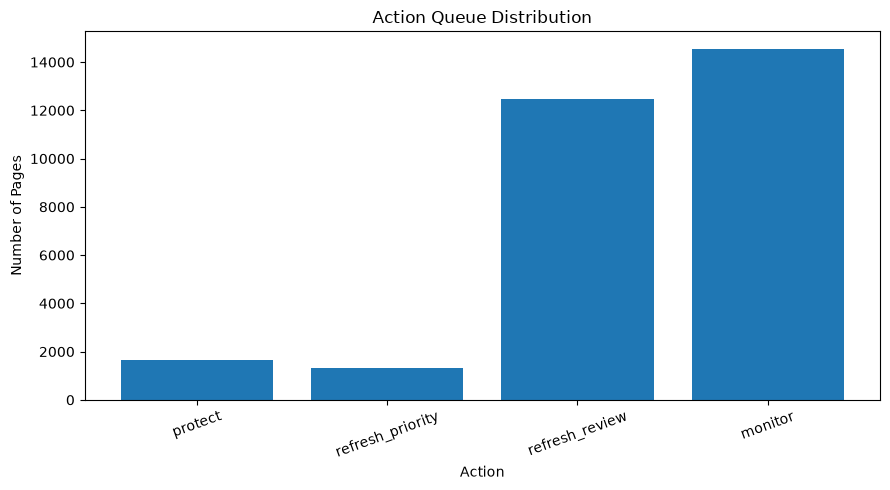

Wrote: ../figures\action_distribution.png


In [17]:
import matplotlib.pyplot as plt

action_order = [
    "protect",
    "refresh_priority",
    "refresh_review",
    "monitor"
]

counts = (
    queue["action"]
    .value_counts()
    .reindex(action_order)
    .fillna(0)
)

plt.figure(figsize=(9, 5))

plt.bar(
    counts.index,
    counts.values
)

plt.title("Action Queue Distribution")
plt.xlabel("Action")
plt.ylabel("Number of Pages")

plt.xticks(rotation=20)
plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "action_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print(f"Wrote: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.